In [1]:
library(dplyr)
library(Seurat)
library(patchwork)
library(ggplot2)
library(harmony)


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Loading required package: SeuratObject

Loading required package: sp


Attaching package: ‘SeuratObject’


The following objects are masked from ‘package:base’:

    intersect, t


Loading required package: Rcpp



In [32]:
all <- readRDS("/storage/riosugimuralab/alexto/A2_AssemFlex/Flex.rds")

In [33]:
# View the exact R call string and parameters
all@commands$RunPCA@params
all@commands$RunUMAP@params

$assay
[1] "RNA"

$npcs
[1] 50

$rev.pca
[1] FALSE

$weight.by.var
[1] TRUE

$verbose
[1] TRUE

$ndims.print
[1] 1 2 3 4 5

$nfeatures.print
[1] 30

$reduction.name
[1] "pca"

$reduction.key
[1] "PC_"

$seed.use
[1] 42

$dims
 [1]  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25
[26] 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47 48 49 50

$reduction
[1] "pca"

$assay
[1] "RNA"

$slot
[1] "data"

$umap.method
[1] "uwot"

$return.model
[1] FALSE

$n.neighbors
[1] 30

$n.components
[1] 2

$metric
[1] "cosine"

$learning.rate
[1] 1

$min.dist
[1] 0.3

$spread
[1] 1

$set.op.mix.ratio
[1] 1

$local.connectivity
[1] 1

$repulsion.strength
[1] 1

$negative.sample.rate
[1] 5

$uwot.sgd
[1] FALSE

$seed.use
[1] 42

$angular.rp.forest
[1] FALSE

$densmap
[1] FALSE

$dens.lambda
[1] 2

$dens.frac
[1] 0.3

$dens.var.shift
[1] 0.1

$verbose
[1] TRUE

$reduction.name
[1] "umap.unintegrated"

In [37]:
# View the summary stats (Min, Median, Max, etc.) for counts and features
summary(all@meta.data[, c("nCount_RNA", "nFeature_RNA")])

   nCount_RNA      nFeature_RNA  
 Min.   :   457   Min.   :  206  
 1st Qu.: 10004   1st Qu.: 4013  
 Median : 14906   Median : 4914  
 Mean   : 17312   Mean   : 4832  
 3rd Qu.: 21588   3rd Qu.: 5797  
 Max.   :262966   Max.   :11241  

In [44]:
levels(all@meta.data$cell_type)
levels(all@meta.data$orig.ident)

[1] "CD16+ Mac"    "IL1B+ Mac"    "GLUL+ Mac"    "FOLR2+ Mac"   "TREM2+ Mac"  
 [6] "FABP5+ Mac"   "C3+ Mac"      "ISG15+ Mac"   "HK2+ Mac"     "GAS6+ Mac"   
[11] "CSF3R+ Mac"   "NR4A1+ Mac"   "Prolif Mac-1" "Prolif Mac-2" "Prolif Mac-3"
[16] "Mast_cell"    "Fibroblast"   "Endothelium"  "Tumor"        "Mixed"       
[21] "Unknown_1"    "Unknown_2"

[1] "Assembloid" "VIO"

In [42]:
library(scCustomize)
cell_types <- levels(Idents(all))
all$cell_type <- Idents(all)
pal <- DiscretePalette_scCustomize(num_colors = length(cell_types), palette = "stepped")
names(pal) <- cell_types

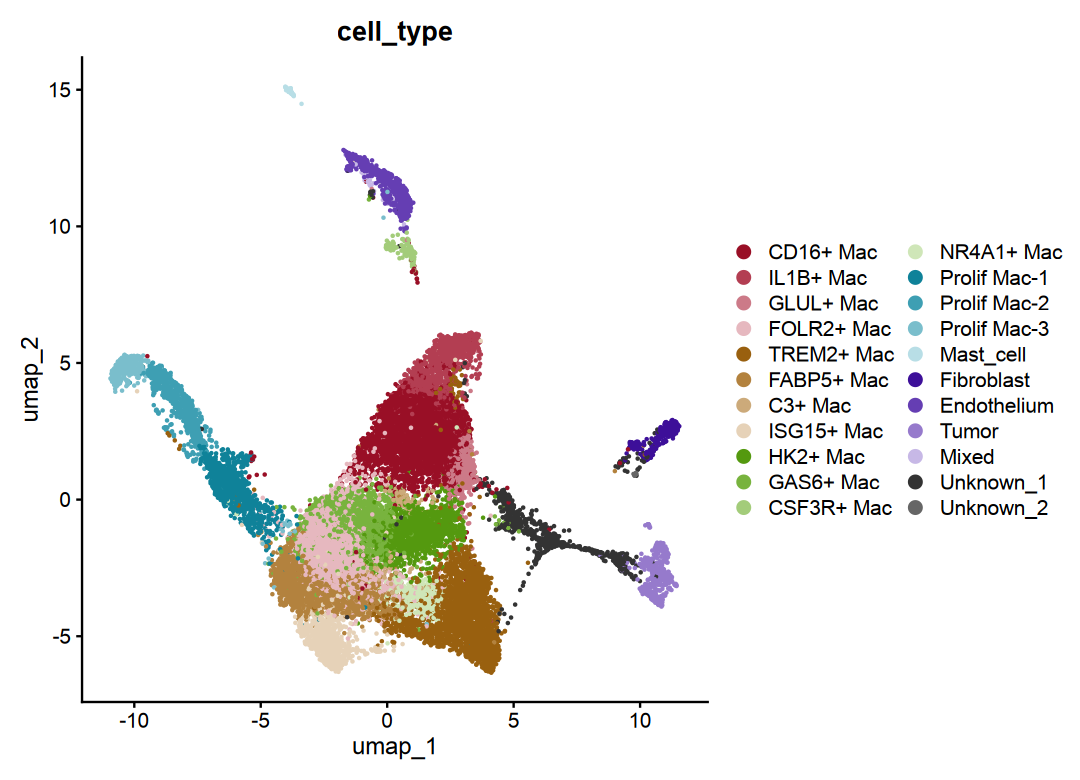

In [43]:
options(repr.plot.width = 9, repr.plot.height = 6.5)
DimPlot(all, group.by="cell_type",cols = pal)

In [47]:
# Extract cell type distribution data
meta <- all@meta.data
tab <- table(meta$cell_type, meta$orig.ident)
df_wide <- as.data.frame.matrix(tab)
df_wide$cell_type <- rownames(df_wide)

celltype_by_origident_df <- df_wide[, c("cell_type", "Assembloid", "VIO")]
celltype_by_origident_df

,cell_type,Assembloid,VIO
,<chr>,<int>,<int>
CD16+ Mac,CD16+ Mac,3547,160
IL1B+ Mac,IL1B+ Mac,1171,1
GLUL+ Mac,GLUL+ Mac,473,7
FOLR2+ Mac,FOLR2+ Mac,123,2761
TREM2+ Mac,TREM2+ Mac,641,1725
FABP5+ Mac,FABP5+ Mac,22,1902
C3+ Mac,C3+ Mac,9,137
ISG15+ Mac,ISG15+ Mac,15,862
HK2+ Mac,HK2+ Mac,159,1309


Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.


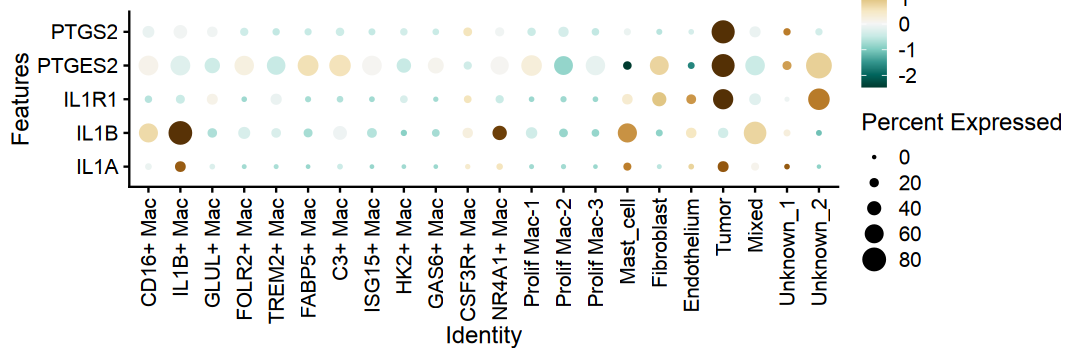

In [48]:
options(repr.plot.width = 9, repr.plot.height = 3)
library(RColorBrewer)
DotPlot(all, features=c('IL1A', 'IL1B', 'IL1R1', 'PTGES2', 'PTGS2'), group.by='cell_type') + 
scale_colour_gradientn(colours = rev(brewer.pal(n = 11, name = "BrBG"))) + 
  theme(axis.text.x = element_text(angle = 90, hjust = 1, vjust = 0.5)) + coord_flip()

Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.


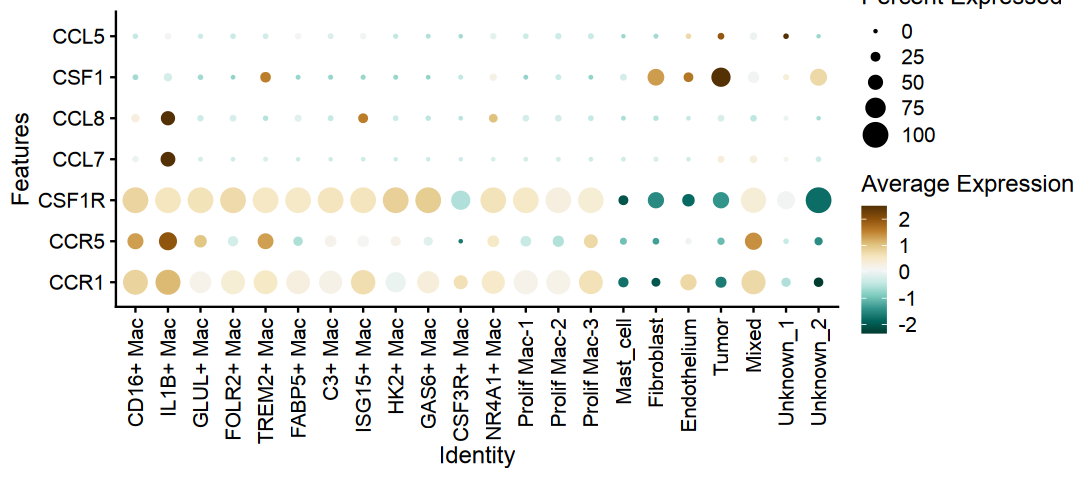

In [49]:
options(repr.plot.width = 9, repr.plot.height = 4)
library(RColorBrewer)
DotPlot(all, features=c('CCR1', 'CCR5','CSF1R', 'CCL7','CCL8','CSF1','CCL5'), group.by='cell_type') + 
scale_colour_gradientn(colours = rev(brewer.pal(n = 11, name = "BrBG"))) + 
  theme(axis.text.x = element_text(angle = 90, hjust = 1, vjust = 0.5)) + coord_flip()